In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the CSV file
# Assuming the file is directly in your Google Drive 'My Drive' folder
train_csv_path = '/content/drive/MyDrive/ML1 - Final Project/employee_attrition_TRAIN_DATASET.csv'
test_csv_path = '/content/drive/MyDrive/ML1 - Final Project/employee_attrition_TEST_DATASET.csv'


# Import the CSV file into a pandas DataFrame
try:
    train_df = pd.read_csv(train_csv_path)
    print("CSV file imported successfully!")
    print(f"Train DataFrame shape: {train_df.shape}")
    print(train_df.head())
except FileNotFoundError:
    print(f"Error: The file '{train_csv_path}' was not found. Please ensure it is in your Google Drive 'My Drive' folder.")
except Exception as e:
    print(f"An error occurred: {e}")

# Import the CSV file into a pandas DataFrame
try:
    test_df = pd.read_csv(test_csv_path)
    print("CSV file imported successfully!")
    print(f"Test DataFrame shape: {test_df.shape}")
    print(test_df.head())
except FileNotFoundError:
    print(f"Error: The file '{test_csv_path}' was not found. Please ensure it is in your Google Drive 'My Drive' folder.")
except Exception as e:
    print(f"An error occurred: {e}")

Mounted at /content/drive
CSV file imported successfully!
Train DataFrame shape: (1029, 51)
   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   19          0             1.0        645         1.0                 9   
1   33          1             1.0       1277         1.0                15   
2   52          0             1.0       1325         1.0                11   
3   27          0             2.0        591         1.0                 2   
4   34          0             2.0        303         2.0                 2   

   Education  EducationField  EnvironmentSatisfaction  HourlyRate  ...  \
0          2             1.0                        3          54  ...   
1          1             3.0                        2          56  ...   
2          4             1.0                        4          82  ...   
3          3             3.0                        4          87  ...   
4          4             2.0                        3          75  ..

## Logistic Regression

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params:    {'lr__C': 0.01, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Best CV AUC:    0.8311

=== Logistic Regression — Grid Search ===

Test AUC-ROC: 0.8182

              precision    recall  f1-score   support

No Attrition       0.93      0.71      0.80       370
   Attrition       0.33      0.73      0.45        71

    accuracy                           0.71       441
   macro avg       0.63      0.72      0.63       441
weighted avg       0.83      0.71      0.75       441



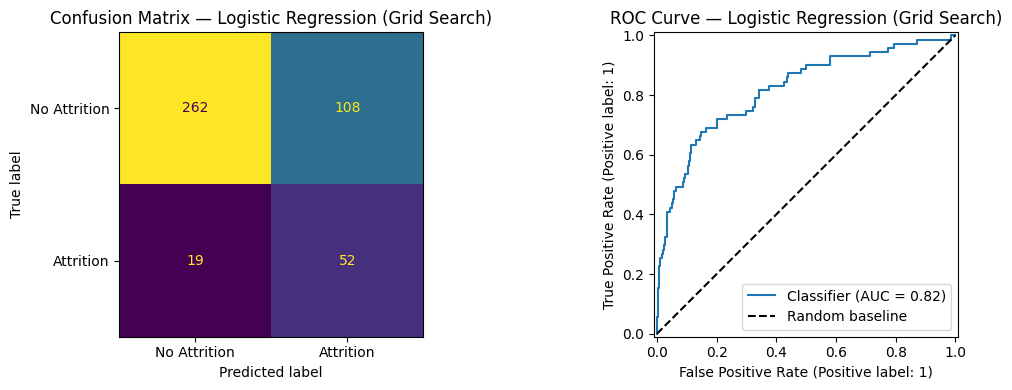

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# --- Prep ---
drop_cols = ["Attrition", "AgeBand"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Attrition"]
X_test  = test_df[feature_cols]
y_test  = test_df["Attrition"]

# --- Pipeline: Scale + Fit together ---
# Using a pipeline ensures the scaler is fit only on each CV training fold,
# not the validation fold — same leakage logic as everywhere else.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

param_grid = {
    "lr__C":       [0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l1", "l2"],
    "lr__solver":  ["liblinear"]  # supports both l1 and l2
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,                  # 5-fold cross-validation
    scoring="roc_auc",     # optimize for AUC
    n_jobs=-1,             # use all cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best params:    {grid_search.best_params_}")
print(f"Best CV AUC:    {grid_search.best_score_:.4f}")

# --- Evaluate best model on test set ---
best_model = grid_search.best_estimator_

y_pred       = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression — Grid Search ===\n")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Attrition", "Attrition"]))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Attrition", "Attrition"],
    ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix — Logistic Regression (Grid Search)")

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
axes[1].set_title("ROC Curve — Logistic Regression (Grid Search)")
axes[1].plot([0, 1], [0, 1], "k--", label="Random baseline")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Logistic Regression Takeaways
We fit a logistic regression with 5-fold cross-validated grid search over regularization strength (C) and penalty type (L1 vs L2). The best parameters were C=0.01 with L2 regularization — heavy regularization winning suggests that many features share overlapping signal, consistent with the multicollinearity identified during EDA.

The model achieved a test AUC of 0.82, with near-identical CV AUC (0.831), indicating clean generalization and no overfitting. On the minority class, the model reached 73% recall (catching nearly 3 in 4 true flight risks) at the cost of lower precision (0.33), meaning a meaningful share of flagged employees are false positives. This tradeoff is acceptable given the low cost of a false positive in an HR retention context.

Overall this is a strong baseline. The 0.82 AUC is the benchmark for advanced models to beat, and the heavy regularization result suggests that tree-based methods, which handle multicollinearity natively, may yield further gains.

## Initialize Results Tracker

In [ ]:
import pandas as pd

# Initialize once at the start of your modeling section
results = []

# After each model, append a row
results.append({
    "Model":                "Logistic Regression",
    "CV AUC":               0.831,
    "Test AUC":             0.818,
    "Attrition Precision":  0.33,
    "Attrition Recall":     0.73,
    "Attrition F1":         0.45,
    "Notes":                "C=0.01, L2; heavy regularization suggests multicollinearity"
})

# Display
results_df = pd.DataFrame(results)
results_df.set_index("Model", inplace=True)
print(results_df)

                     CV AUC  Test AUC  Attrition Precision  Attrition Recall  \
Model                                                                          
Logistic Regression   0.831     0.818                 0.33              0.73   

                     Attrition F1  \
Model                               
Logistic Regression          0.45   

                                                                 Notes  
Model                                                                   
Logistic Regression  C=0.01, L2; heavy regularization suggests mult...  


## Decision Tree

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params:  {'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__min_samples_leaf': 25}
Best CV AUC:  0.7359

=== Decision Tree — Grid Search ===

Test AUC-ROC: 0.6775

              precision    recall  f1-score   support

No Attrition       0.90      0.68      0.77       370
   Attrition       0.27      0.62      0.37        71

    accuracy                           0.67       441
   macro avg       0.59      0.65      0.57       441
weighted avg       0.80      0.67      0.71       441



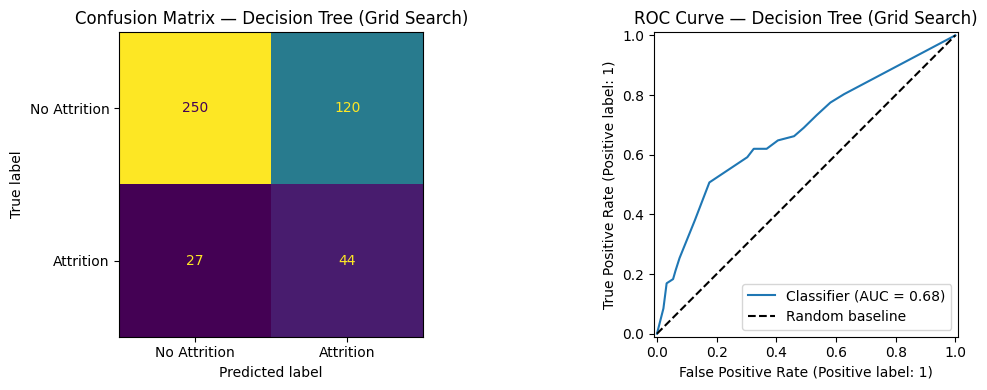

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# --- Prep ---
# Reuse same feature_cols and X/y splits from logistic regression
# (No scaling needed — decision trees are scale-invariant)

pipe_dt = Pipeline([
    ("dt", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_dt = {
    "dt__max_depth":        [3, 5, 7, 10, 12, None],  # None = fully grown (will overfit)
    "dt__min_samples_leaf": [1, 5, 10, 20, 25],        # min samples required at a leaf node
    "dt__criterion":        ["gini", "entropy"]    # split quality measure
}

grid_search_dt = GridSearchCV(
    pipe_dt,
    param_grid_dt,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

print(f"Best params:  {grid_search_dt.best_params_}")
print(f"Best CV AUC:  {grid_search_dt.best_score_:.4f}")

# --- Evaluate on test set ---
best_dt = grid_search_dt.best_estimator_

y_pred_dt       = best_dt.predict(X_test)
y_pred_proba_dt = best_dt.predict_proba(X_test)[:, 1]

print("\n=== Decision Tree — Grid Search ===\n")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=["No Attrition", "Attrition"]))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=["No Attrition", "Attrition"],
    ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix — Decision Tree (Grid Search)")

RocCurveDisplay.from_predictions(y_test, y_pred_proba_dt, ax=axes[1])
axes[1].set_title("ROC Curve — Decision Tree (Grid Search)")
axes[1].plot([0, 1], [0, 1], "k--", label="Random baseline")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
results.append({
    "Model":                "Decision Tree",
    "CV AUC":               grid_search_dt.best_score_,
    "Test AUC":             roc_auc_score(y_test, y_pred_proba_dt),
    "Attrition Precision":  0.26,
    "Attrition Recall":     0.65,
    "Attrition F1":         0.37,
    "Notes":                f"Best params: {grid_search_dt.best_params_}"
})

results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

                       CV AUC  Test AUC  Attrition Precision  \
Model                                                          
Logistic Regression  0.831000  0.818000                 0.33   
Decision Tree        0.735933  0.677484                 0.26   

                     Attrition Recall  Attrition F1  \
Model                                                 
Logistic Regression              0.73          0.45   
Decision Tree                    0.65          0.37   

                                                                 Notes  
Model                                                                   
Logistic Regression  C=0.01, L2; heavy regularization suggests mult...  
Decision Tree        Best params: {'dt__criterion': 'gini', 'dt__ma...  


#### Decision Tree Takeaways
We fit a decision tree with 5-fold cross-validated grid search over max_depth, min_samples_leaf, and split criterion. The best parameters were max_depth=5, min_samples_leaf=25, and gini — the grid search needing to heavily constrain the tree to achieve any generalization is itself a signal that a single tree struggles with this feature set.

The model achieved a test AUC of 0.68, meaningfully below the logistic regression benchmark of 0.82. The CV-to-test AUC gap (0.736 → 0.678) is also wider than logistic regression, indicating some residual overfitting even with regularization. On the minority class, attrition recall dropped to 0.62 and F1 to 0.37 — weaker on both counts than logistic regression.

The underperformance is expected. A single decision tree partitions feature space with hard rectangular cuts, which handles the continuous engineered ratio features (e.g. PromotionVelocityLog, IncomeVsPeers) less gracefully than logistic regression. It also cannot average out noise the way an ensemble can. This sets up a clear narrative for Random Forest — bagging directly addresses the variance problem visible here, and the ensemble recovers nonlinear flexibility without the overfitting penalty.

The logistic regression AUC of 0.82 remains the baseline benchmark heading into advanced modeling.

# XGBoost Gradient

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import shap

# --- Prep ---
drop_cols = ["Attrition", "AgeBand"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df["Attrition"]
X_test  = test_df[feature_cols]
y_test  = test_df["Attrition"]

# --- Determine parameter ranges ---
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 1]
}

# --- Train XGBoost on train data ---
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# --- Randomized search ---
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=80,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42
)

xgb_random_search.fit(X_train, y_train)

print("Best params:", xgb_random_search.best_params_)
print("Best CV AUC:", round(xgb_random_search.best_score_, 4))

Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}
Best CV AUC: 0.8306


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:57:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# --- Evaluate best model on test set ---
best_xgb = xgb_random_search.best_estimator_
y_test_pred_xgb = best_xgb.predict(X_test)
y_test_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("Confusion Matrix - Test (XGB)")
print(confusion_matrix(y_test, y_test_pred_xgb))
print("\nClassification Report - Test (XGB)")
print(classification_report(y_test, y_test_pred_xgb))
print("Test ROC AUC (XGB):", roc_auc_score(y_test, y_test_proba_xgb))

Confusion Matrix - Test (XGB)
[[359  11]
 [ 54  17]]

Classification Report - Test (XGB)
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       370
           1       0.61      0.24      0.34        71

    accuracy                           0.85       441
   macro avg       0.74      0.60      0.63       441
weighted avg       0.83      0.85      0.82       441

Test ROC AUC (XGB): 0.7653977921583555


#### XGBoost Gradient
We fit an XGBoost gradient-boosted tree model with 5-fold randomized search over learning rate, depth, number of trees, subsample, column subsaple and gamma. The best configuration used a relatively shallow depth (max_depth = 3), with moderate learning rate and subsampling.

The model achieve a CV AUC of 0.83 and a test AUC of 0.77, slightly below the logistic regression benchmark of 0.82 but above the single decision tree's 0.68. The CV-test gap is modest, suggesting reasonable generalization but some slight overfitting may be at play.

Given the business context where the cost of a false positive is relatively low, the logistic regression remains the preferred model from a recall-driven retention perspective, with XGBoost proiding useful nonlinear benchmark.

# SHAP Analysis

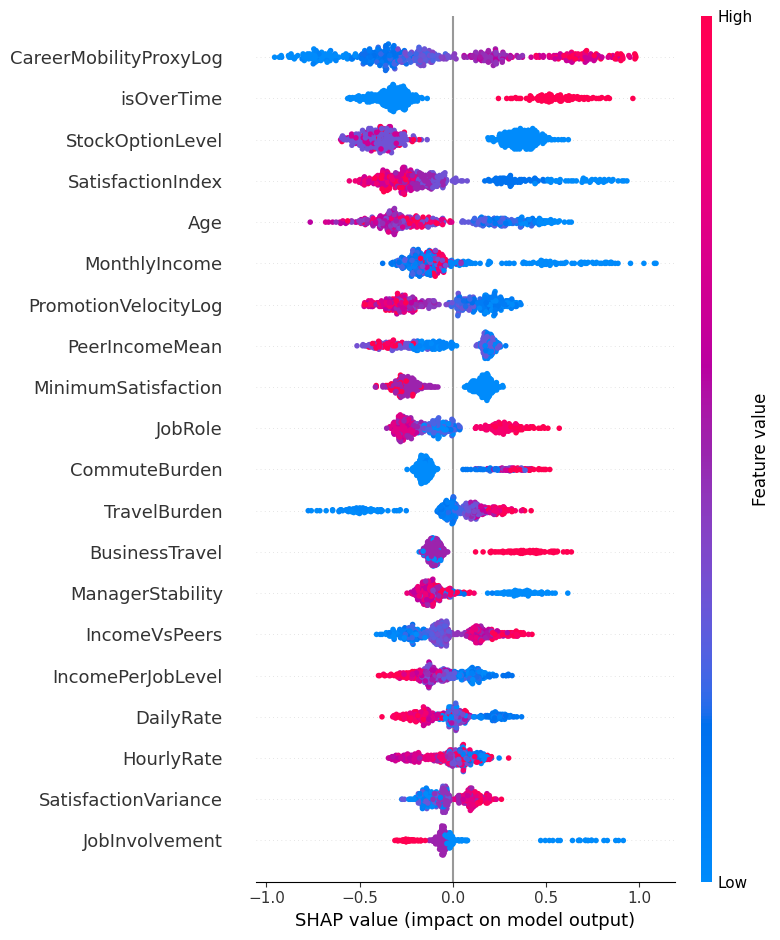

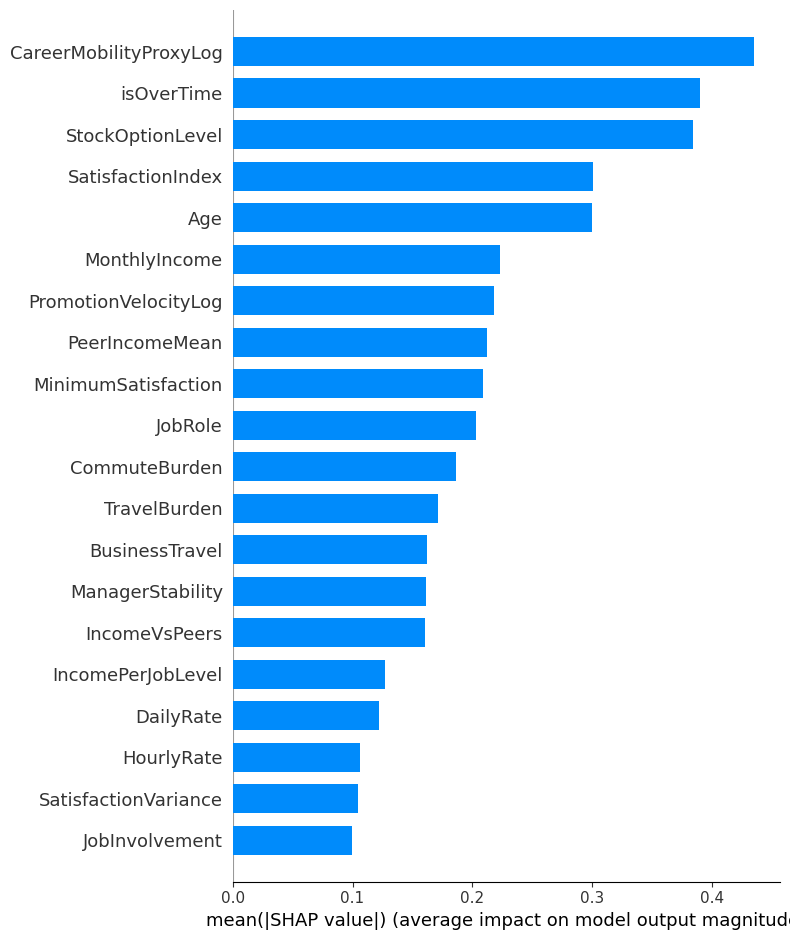

In [ ]:
# --- Build TreeExplainer for your tuned XGBoost model ---
explainer = shap.TreeExplainer(best_xgb)

# --- Compute SHAP values on test set ---
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list) or isinstance(shap_values, tuple):
    shap_vals_pos = shap_values[1]
else:
    shap_vals_pos = shap_values

# --- Global importance: summary beeswarm ---
shap.summary_plot(
    shap_vals_pos,
    X_test,
    plot_type="dot",
)

# --- Global importance: mean |SHAP| bar plot ---
shap.summary_plot(
    shap_vals_pos,
    X_test,
    plot_type="bar",
)


#### SHAP Takeaways
SHAP values decompose each XGBoost prediction into feature-level contributions, allowing us to see which factors most strongly push an employee towards staying or leaving.

Higher CareerMobilityProxyLog values tend to have negative SHAP values, indicating that better internal mobility prospects reduce attrition risk, while lower values push risk up. Employees marked as over‑time (isOverTime = 1) typically show positive SHAP contributions, consistent with overtime work increasing the probability of attrition. Higher StockOptionLevel and higher SatisfactionIndex are mostly associated with negative SHAP contributions, suggesting equity and overall satisfaction are stabilizing factors.

Income‑related and burden‑related features such as MonthlyIncome, PeerIncomeMean, IncomeVsPeers, CommuteBurden, and TravelBurden still matter but rank below the core mobility, overtime, and satisfaction drivers in average impact. ManagerStability and PromotionVelocityLog appear as secondary levers, with more stable managers and faster promotion velocity reducing predicted attrition.